In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import papermill as pm

from exocrires import info

#0308 d=10 pixel
#0209 d=15 pixel
#0309 d=5 pixel
#0409 d=3 pixel

path='/Users/richard/project_EXOCRIRES/'
day='0308'
log_file = 'simulation_log_10.csv'
simulation_parameters = pd.read_csv(path + '%s'%log_file)



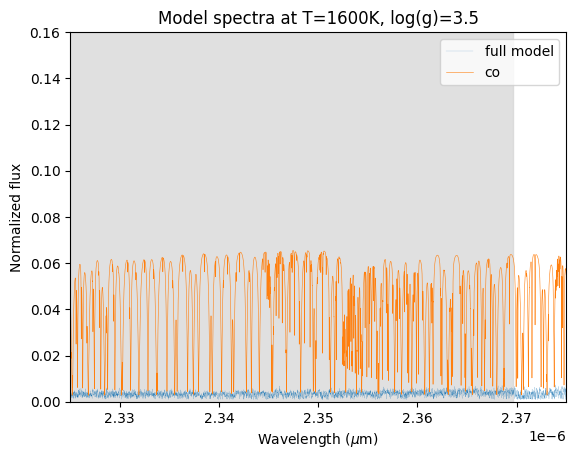

In [2]:
fMod_ch4=np.load(path+'f_pRT_ch4_only_t1600_g100nc_m0.0.npy')
fMod_co=np.load(path+'f_pRT_co_only_t1600_g100nc_m0.0.npy')
fMod_h2o=np.load(path+'f_pRT_h2o_pokazatel_only_t1600_g100nc_m0.0.npy')
fMod=np.load(path+'f_pRT_t1600_g100nc_m0.0.npy')

#k_ch4=np.nanmax(fMod)/np.nanmax(fMod_ch4)
#k_co=np.nanmax(fMod)/np.nanmax(fMod_co)


fMod /= np.nanmax(fMod)
fMod_ch4 /= np.nanmax(fMod_ch4)
fMod_co /= np.nanmax(fMod_co)
fMod_h2o /= np.nanmax(fMod_h2o)


wMod = np.load(path+'wave_pRT.npy')
wMod = wMod * 1e-6 #m

lambda_range=info.lambda_range

mask_full=np.array(wMod*1e9>lambda_range['wave'][3][1][1])
mask_mo=np.array(wMod*1e9>lambda_range['wave'][3][1][1])

plt.plot(wMod, fMod, linewidth=0.1, label='full model')
plt.plot(wMod, fMod_co, linewidth=0.4,label='co')
#plt.plot(wMod, fMod_ch4, linewidth=0.4, label='ch4',alpha=0.7)
#plt.plot(wMod, fMod_h2o, linewidth=0.4, label='h2o', alpha=0.5)

for i in range(2, 7):

    wave_min= lambda_range['wave'][3][i][0]*1e-9
    wave_max=lambda_range['wave'][3][i][-1]*1e-9
    plt.axvspan(wave_min, wave_max, color='lightgray', alpha=0.7)

plt.xlim(2.325e-6,2.375e-6)
plt.ylim(0,0.16)
plt.xlabel('Wavelength ($\mu$m)')
plt.ylabel('Normalized flux')
plt.title('Model spectra at T=1600K, log(g)=3.5')
plt.legend()
plt.show()

In [ ]:
#This script aims to create the necessary data structures for every simulation run and download certain theoretical data from the online spectral libriaries.
#Input the necsseary paramters for downloading the data
#The parameters are the following:



for i in simulation_parameters.index[5:]:

    T_p = simulation_parameters['Teff_planet'][i]  # in K
    G_p = simulation_parameters['G_planet'][i]  # in log10 cm/s^2
    M_p = simulation_parameters['M_planet'][i]  # in Mjup
    R_p = simulation_parameters['R_planet'][i]  # in Rjup
    Z_p = simulation_parameters['Z_planet'][i]  # in [Zsun]

    T_s = simulation_parameters['Teff_star'][i]  # in K
    Z_s = simulation_parameters['Z_star'][i]  # in [Zsun]
    R_s = simulation_parameters['R_star'][i]  # in Rsun
    G_s = simulation_parameters['G_star'][i]  # in log10 cm/s^2

    Age = simulation_parameters['Age'][i]  # in Myr, round 2 decimal places
    Age = round(Age, 2)
    Scenario = simulation_parameters['formation_scenario'][i]  # 'H' for hot start, 'C' for cold start

    data_star = pd.read_csv(path + 'data_BHAC15.csv')
    
    #create the folder structure for the simulation

    folder_name = f'{Scenario}{T_p}_{M_p}_{R_p}_{Age}'

    #if not os.path.exists(path + folder_name):
    os.makedirs(path + folder_name, exist_ok=True)
    os.makedirs(path + folder_name + '/spectra_input', exist_ok=True)
    os.makedirs(path + folder_name + '/%s'%day, exist_ok=True)
    os.makedirs(path + folder_name +'/%s/star'%day, exist_ok=True)
    os.makedirs(path + folder_name + '/%s/planet'%day, exist_ok=True)
    os.makedirs(path + folder_name + '/%s/sky'%day, exist_ok=True)
    os.makedirs(path + folder_name + '/plots', exist_ok=True)

    #copy the necessary files to the new folder
    os.system('cp %setc_cli.py %s%s/'%(path, path, folder_name)) #etc_cli.csv is the file with the parameters for the ETC input
    os.system('cp %setc_json2ascii.py %s%s/'%(path, path, folder_name)) #etc_json2ascii is the script to convert the json files to ascii files
    os.system('cp %swave_pRT.npy %s%s/'%(path, path, folder_name)) #wave_pRT.npy is the wavelength grid for the pRT code
    os.system('cp %sWAVE_PHOENIX-ACES-AGSS-COND-2011.fits %s%s/'%(path, path, folder_name)) #WAVE_PHOENIX-ACES-AGSS-COND-2011.fits is the wavelength grid for the PHOENIX spectra


    #Download the PHOENIX spectra for the star
    Z_s = int(Z_s *2)/2 # round to the nearest 0.5
    if Z_s  == 0.0:
        Z_s = -0.0

    T_s = int(T_s / 100) * 100  # round to the nearest 100
    G_s = int(G_s / 0.5) * 0.5  # round to the nearest 0.5


    path_library='ftp://phoenix.astro.physik.uni-goettingen.de/HiResFITS/PHOENIX-ACES-AGSS-COND-2011/'
    path_spectrum ='Z%s/lte0%s-%s0%s.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits'%(Z_s, T_s, G_s, Z_s)
    name_spectrum = '/lte0%s-%s0%s.PHOENIX-ACES-AGSS-COND-2011-HiRes.fits'%(T_s, G_s, Z_s)
    
    if not os.path.exists(path + folder_name + name_spectrum):
        os.system('wget %s%s -P %s%s'%(path_library, path_spectrum, path, folder_name))
    else:
        print('The star spectrum already exists, skipping download')
    

    #Download the pRT spectrum for the planet from Google Drive
    #Do it manually, as the link is not accessible via wget

    #Employ papermil to run the first notebook with the parameters
    pm.execute_notebook(
        path + 'spectra_preparation.ipynb',
        path + folder_name + '/spectra_preparation.ipynb',
        parameters={
            'T_planet': int(T_p),
            'G_planet': float(G_p),
            'M_planet': int(M_p),
            'R_planet': float(R_p),
            'Z_planet': float(Z_p),
            'T_star': int(T_s),
            'Z_star': float(Z_s),
            'R_star': float(R_s),
            'G_star': float(G_s),
            'folder_name': folder_name,
            'Age': float(Age)
        }
    )

    #We don't need to create the folders and prepare the spectra again if they already exist
    '''
    elif not os.path.exists(path + folder_name + '/%s'%day):
        
        os.makedirs(path + folder_name + '/%s'%day, exist_ok=True)
        os.makedirs(path + folder_name + '/%s/star'%day, exist_ok=True)
        os.makedirs(path + folder_name + '/%s/planet'%day, exist_ok=True)
        os.makedirs(path + folder_name + '/%s/sky'%day, exist_ok=True)
        os.makedirs(path + folder_name + '/plots', exist_ok=True)
    '''  


The star spectrum already exists, skipping download


Executing:   0%|          | 0/21 [00:00<?, ?cell/s]

python(41033) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


KeyboardInterrupt: 

In [3]:
#excute the second notebook to prepare the spectra
simulation_parameters = pd.read_csv(path + '%s'%log_file)
change_only_position = True  #If you have already created the folders and prepared the spectra but just want to change the location of the plaents, you follow this step:

print ('The position is:', simulation_parameters['sep_pix'][0], 'pixels')

for i in simulation_parameters.index:
    T_p = simulation_parameters['Teff_planet'][i]  # in K
    Z_p = simulation_parameters['Z_planet'][i]  # in [Zsun]
    R_p = simulation_parameters['R_planet'][i]  # in Rjup
    M_p = simulation_parameters['M_planet'][i]  # in Mjup
    G_p = simulation_parameters['G_planet'][i]  # in log10 cm/s^2
    Sep_p = simulation_parameters['sep_pix'][i]  # in pixels
    Z_s= simulation_parameters['Z_star'][i]  # in [Zsun]
    
    Age = simulation_parameters['Age'][i]  # in Myr, round 2 decimal places
    Scenario = simulation_parameters['formation_scenario'][i]  # 'H' for hot start, 'C' for cold start

    folder_name = f'{Scenario}{T_p}_{M_p}_{R_p}_{Age}'
    print ('We are processing the folder: ', folder_name)

    Mag_p_K = simulation_parameters['Mag_planet_K'][i]  # in K band, from the simulation log
    Mag_s_K = simulation_parameters['Mag_star_K'][i]  # in K band, from the simulation log

    #if you have already created the folders and prepared the spectra but just want to change the location of the plaents, you follow this step:
    #Copy the necessary simulation files to the new folder
    #select a existing folder and copy the files
    if change_only_position == True:
        folder_existing_day = '0409'
        band='K2166'
        model_name='%s-%s-%s'%(T_p, G_p, Z_p)
    
        os.makedirs(path + folder_name + '/%s/star/%s'%(day,band), exist_ok=True)
        os.makedirs(path + folder_name + '/%s/planet/%s/%s'%(day,model_name,band), exist_ok=True)
        os.makedirs(path + folder_name + '/%s/sky/%s'%(day,band), exist_ok=True)


        os.system('cp -r %s/%s/%s/star/%s/stellar_simu_K2166.csv %s/%s/%s/star/%s/'%(path, folder_name, folder_existing_day, band, path, folder_name, day, band))
        #copy asci_35 folder into the new location
        os.system('cp -r %s/%s/%s/star/%s/ascii_35 %s/%s/%s/star/%s/'%(path, folder_name, folder_existing_day, band, path, folder_name, day, band))

        os.system('cp -r %s/%s/%s/planet/%s/%s/planet_simu.csv %s/%s/%s/planet/%s/%s/'%(path, folder_name, folder_existing_day, model_name, band, path, folder_name, day, model_name, band))
        os.system('cp -r %s/%s/%s/sky/%s/sky_simu.csv %s/%s/%s/sky/%s/'%(path, folder_name, folder_existing_day, band, path, folder_name, day, band))

        
        pm.execute_notebook(
            path + 'EXOCRIRES_2dspectra_short.ipynb',
            path + folder_name + '/EXOCRIRES_2dspectra_short.ipynb',
            parameters={
                'Scenario': Scenario,
                'T_planet': int(T_p),
                'Z_planet': float(Z_p),
                'R_planet': float(R_p),
                'G_planet': float(G_p),
                'Age': float(Age),
                'Mag_star_K': Mag_s_K,
                'Mag_planet_K': Mag_p_K,
                'day': day,
                'folder_name': folder_name,
                'Sep_p': int(Sep_p)
            }
        )
        
    else:
        #Run the notebook to prepare the spectra
        pm.execute_notebook(
            path + 'EXOCRIRES_2dspectra.ipynb',
            path + folder_name + '/EXOCRIRES_2dspectra.ipynb',
            parameters={
                'Scenario': Scenario,
                'T_planet': int(T_p),
                'Z_planet': float(Z_p),
                'R_planet': float(R_p),
                'G_planet': float(G_p),
                'Age': float(Age),
                'Mag_star_K': Mag_s_K,
                'Mag_planet_K': Mag_p_K,
                'day': day,
                'folder_name': folder_name,
                'Sep_p': int(Sep_p)
            }
        )

The position is: 10.0 pixels
We are processing the folder:  H1800_5_1.76_1.37


Executing:   0%|          | 0/8 [00:00<?, ?cell/s]

KeyboardInterrupt: 

In [125]:
#Run the third notebook to prepare the CCFs and likelihood maps
simulation_parameters = pd.read_csv(path + '%s'%log_file)
print ('Planet position: %s pix'%simulation_parameters['sep_pix'][0])

for i in simulation_parameters.index:
    T_p = simulation_parameters['Teff_planet'][i]  # in K
    Z_p = simulation_parameters['Z_planet'][i]  # in [Zsun]
    R_p = simulation_parameters['R_planet'][i]  # in Rjup
    M_p = simulation_parameters['M_planet'][i]  # in Mjup
    G_p = simulation_parameters['G_planet'][i]  # in log10 cm/s^2
    Sep_p = simulation_parameters['sep_pix'][i]  # in pixel
    
    Age = simulation_parameters['Age'][i]  # in Myr, round 2 decimal places
    Scenario = simulation_parameters['formation_scenario'][i]  # 'H' for hot start, 'C' for cold start

    folder_name = f'{Scenario}{T_p}_{M_p}_{R_p}_{Age}'

    Delete_old = 'yes'
    
    pm.execute_notebook(
        path + 'EXOCRIRES_CC.ipynb',
        path + folder_name + '/%s/EXOCRIRES_CC.ipynb'%day,
        parameters={
            'Scenario': Scenario,
            'T_planet': int(T_p),
            'Z_planet': float(Z_p),
            'R_planet': float(R_p),
            'G_planet': float(G_p),
            'Age': float(Age),
            'day': day,
            'folder_name': folder_name,
            'Delete_old': Delete_old,
            'Sep_p': int(Sep_p),
            'log_file': log_file
        }
    )

Planet position: 15.0 pix


Executing:   0%|          | 0/40 [00:00<?, ?cell/s]

python(44960) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Executing:   0%|          | 0/40 [00:00<?, ?cell/s]

python(44982) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


...

python(45108) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Executing:   0%|          | 0/40 [00:00<?, ?cell/s]

python(45115) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Executing:   0%|          | 0/40 [00:00<?, ?cell/s]

python(45126) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [127]:
#Run the forth notebook to prepare the CCFs and likelihood maps
simulation_parameters = pd.read_csv(path + '%s'%log_file)
mol_name = ['CH4', 'CO', 'H2O']

print ('Planet position: %s pix'%simulation_parameters['sep_pix'][0])

for i in simulation_parameters.index[6:]:

    T_p = simulation_parameters['Teff_planet'][i]  # in K
    Z_p = simulation_parameters['Z_planet'][i]  # in [Zsun]
    R_p = simulation_parameters['R_planet'][i]  # in Rjup
    M_p = simulation_parameters['M_planet'][i]  # in Mjup
    G_p = simulation_parameters['G_planet'][i]  # in log10 cm/s^2
    
    Age = simulation_parameters['Age'][i]  # in Myr, round 2 decimal places
    Scenario = simulation_parameters['formation_scenario'][i]  # 'H' for hot start, 'C' for cold start
    Sep_p = simulation_parameters['sep_pix'][i]

    mol_index_start=int(2)
    mol_index_finish=int(5) 

    VMIN=int(-50)
    VMAX=int(50)
    STEP=int(5)


    print ('Molecules in processing:', mol_name[mol_index_start-2:mol_index_finish-2])

    folder_name = f'{Scenario}{T_p}_{M_p}_{R_p}_{Age}'
    
    pm.execute_notebook(
        path + 'EXOCRIRES_likelihood.ipynb',
        path + folder_name + '/%s/EXOCRIRES_likelihood.ipynb'%day,
        parameters={
            'Scenario': Scenario,
            'T_planet': int(T_p),
            'Z_planet': float(Z_p),
            'R_planet': float(R_p),
            'G_planet': float(G_p),
            'Age': float(Age),
            'day': day,
            'folder_name': folder_name,
            'mol_index_start':mol_index_start,
            'mol_index_finish':mol_index_finish,
            'log_file': log_file,
            'Sep_p': int(Sep_p),
            'vmin': VMIN,
            'vmax': VMAX,
            'step': STEP
        }
    )

Planet position: 15.0 pix
Molecules in processing: ['CH4', 'CO', 'H2O']


Executing:   0%|          | 0/9 [00:00<?, ?cell/s]

python(47691) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Molecules in processing: ['CH4', 'CO', 'H2O']


Executing:   0%|          | 0/9 [00:00<?, ?cell/s]

...

Executing:   0%|          | 0/9 [00:00<?, ?cell/s]

python(49569) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Molecules in processing: ['CH4', 'CO', 'H2O']


Executing:   0%|          | 0/9 [00:00<?, ?cell/s]

python(50021) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [ ]:
import concurrent.futures


mol_name = ['CH4', 'CO', 'H2O']
input_nb = path + 'EXOCRIRES_likelihood.ipynb'

def run_molecule_simulation(idx, mol_idx):
    """Run one molecule simulation for a given parameter set."""
    T_p = simulation_parameters['Teff_planet'][idx]
    Z_p = simulation_parameters['Z_planet'][idx]
    R_p = simulation_parameters['R_planet'][idx]
    M_p = simulation_parameters['M_planet'][idx]
    G_p = simulation_parameters['G_planet'][idx]
    Age = simulation_parameters['Age'][idx]
    Scenario = simulation_parameters['formation_scenario'][idx]

    folder_name = f'{Scenario}{T_p}_{M_p}_{R_p}_{Age}'
    output_nb = os.path.join(path, folder_name, f'EXOCRIRES_likelihood_{mol_name[mol_idx-2]}.ipynb')

    print(f'Running simulation {idx} - Molecule: {mol_name[mol_idx-2]}')

    pm.execute_notebook(
        input_nb,
        output_nb,
        parameters={
            'Scenario': Scenario,
            'T_planet': int(T_p),
            'Z_planet': float(Z_p),
            'R_planet': float(R_p),
            'G_planet': float(G_p),
            'Age': float(Age),
            'day': day,
            'folder_name': folder_name,
            'mol_index_start': mol_idx,
            'mol_index_finish': mol_idx+1  # just one molecule
        }
    )

# List of indices to process
indices = simulation_parameters.index[8:]
mol_indices = [4]  # adjust based on mol_name indexing in your notebook

# Parallel execution over simulations and molecules
with concurrent.futures.ThreadPoolExecutor(max_workers=4) as executor:
    futures = []
    for idx in indices:
        for mol_idx in mol_indices:
            futures.append(executor.submit(run_molecule_simulation, idx, mol_idx))
    
    # Wait for all to complete
    for future in concurrent.futures.as_completed(futures):
        future.result()

print("All simulations for all molecules completed. CSVs are updated in place.")
